### Get sea level using the Open Meteo API

<Axes: xlabel='time', ylabel='sea_level_height_msl'>

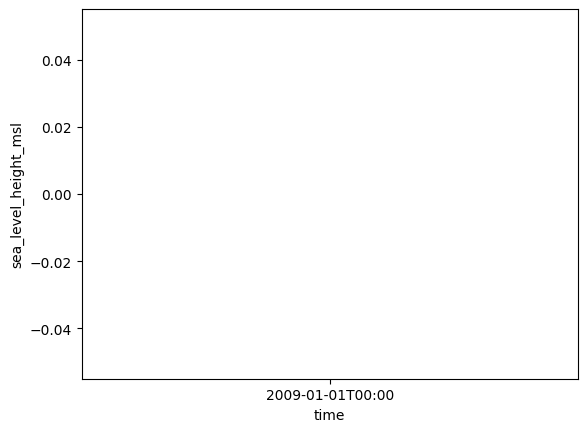

In [11]:
import requests
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from loguru import logger

# Set your query parameters (example: east coast Tasmania)
latitude = -42.0  # Example: Tasmania
longitude = 148.0
start_date = "2009-01-01"
end_date = "2009-12-31"


url: str = (
    f"https://marine-api.open-meteo.com/v1/marine?"
    f"latitude={latitude}&longitude={longitude}"
    f"&hourly=sea_level_height_msl"
    f"&start_date={start_date}&end_date={end_date}"
)

response = requests.get(url)
data = response.json()

# Convert to pandas DataFrame
df = pd.DataFrame(
    {
        "time": data["hourly"]["time"],
        "sea_level_height_msl": data["hourly"]["sea_level_height_msl"],
    }
)


sns.lineplot(x=df["time"], y=df["sea_level_height_msl"])

### Get sea level using the World Tides API

2025-09-11 15:51:42.167 | INFO     | __main__:<module>:67 -              dt  height                  datetime station  latitude  \
0    1230728400   0.216 2008-12-31 13:00:00+00:00    None  -41.1667   
1    1230732000   0.227 2008-12-31 14:00:00+00:00    None  -41.1667   
2    1230735600   0.164 2008-12-31 15:00:00+00:00    None  -41.1667   
3    1230739200   0.056 2008-12-31 16:00:00+00:00    None  -41.1667   
4    1230742800  -0.057 2008-12-31 17:00:00+00:00    None  -41.1667   
..          ...     ...                       ...     ...       ...   
236  1231578000   0.187 2009-01-10 09:00:00+00:00    None  -41.1667   
237  1231581600   0.272 2009-01-10 10:00:00+00:00    None  -41.1667   
238  1231585200   0.239 2009-01-10 11:00:00+00:00    None  -41.1667   
239  1231588800   0.113 2009-01-10 12:00:00+00:00    None  -41.1667   
240  1231592400  -0.055 2009-01-10 13:00:00+00:00    None  -41.1667   

     longitude    atlas  
0      148.333  FES2022  
1      148.333  FES2022  
2      14

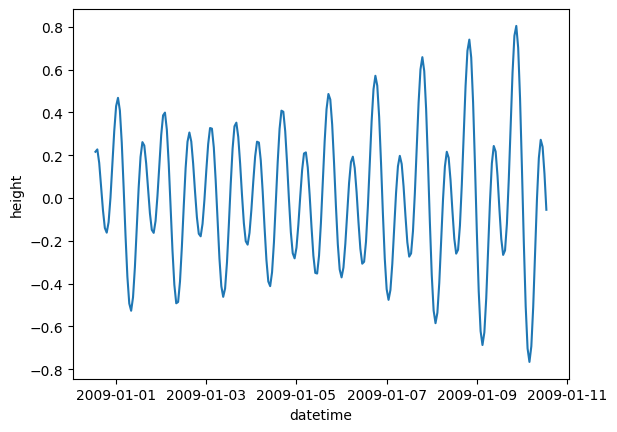

In [12]:
import requests
import pandas as pd
import dotenv
import arrow

dotenv.load_dotenv()


def request_sealevel_worldtides(
    longitude: float, latitude: float, start_date: str
) -> pd.DataFrame:
    """
    Requests sea level data from the World Tides API.
    Parameters:
        longitude: Longitude in decimal degrees.
        latitude: Latitutde in decimal degrees.
        start_date: Start date in format YYYYMMDD
    Returns:
        DataFrame of results
    """
    assert longitude > -180 and longitude < 180, (
        f"longitude must be between -180 and 180, got: {longitude}"
    )
    assert latitude > -90 and latitude < 90, (
        f"latitude must be between -90 and 90, got: {latitude}"
    )
    assert "WORLDTIDES_API_KEY" in dotenv.dotenv_values(), (
        "missing .env value: 'WORLDTIDES_API_KEY'"
    )

    url = "https://www.worldtides.info/api/v3"
    params = {
        "heights": "",
        "date": "2009-01-01",
        "days": 10,
        "step": 3600,  # seconds (1 hour)
        "lat": latitude,
        "lon": longitude,
        "key": dotenv.dotenv_values().get("WORLDTIDES_API_KEY"),
    }

    # NOTE: Data fields from World Tides API
    # 'status', 'callCount', 'copyright',
    # 'requestLat', 'requestLon', 'responseLat',
    # 'responseLon', 'atlas', 'station', 'heights'
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    # Parse data
    df = pd.DataFrame(data["heights"])
    df["datetime"] = pd.to_datetime(df["date"])
    df = df.drop(columns=["date"])

    # Add metadata
    df["station"] = data.get("station")
    df["latitude"] = data.get("responseLat")
    df["longitude"] = data.get("responseLon")
    df["atlas"] = data.get("atlas")

    return df


# NOTE: Elephant rocks, Tasmania
longitude: float = 148.34169
latitude: float = -41.25289

start_date: str = "20090101"

df: pd.DataFrame = request_sealevel_worldtides(
    longitude=longitude, latitude=latitude, start_date=start_date
)
logger.info(df)

figure: plt.Figure = plt.figure()
sns.lineplot(x=df["datetime"], y=df["height"])
figure.show()

### Get sea level using Stormglass API

In [13]:
def request_sealevel_stormglass(
    longitude: float, latitude: float, start_date: str, end_date: str
) -> pd.DataFrame:
    """
    Requests sea level from the Stormglass API.

    Parameters:
        longitude: Longitude in decimal degrees
        latitude: Latitude in decimal degrees
        start_date: Start date in format YYYYMMDD
        end_date: End date in format YYYYMMDD
    Returns:
        DataFrame with results
    """
    assert longitude > -180 and longitude < 180, (
        f"longitude must be between -180 and 180, got: {longitude}"
    )
    assert latitude > -90 and latitude < 90, (
        f"latitude must be between -90 and 90, got: {latitude}"
    )
    assert "STORMGLASS_API_KEY" in dotenv.dotenv_values(), (
        "missing .env value: 'STORMGLASS_API_KEY'"
    )

    start_time: arrow.Arrow = arrow.get(start_date, "YYYYMMDD")
    end_time: arrow.Arrow = arrow.get(end_date, "YYYYMMDD")

    response: requests.Response = requests.get(
        "https://api.stormglass.io/v2/tide/sea-level/point",
        params={
            "lng": longitude,
            "lat": latitude,
            "start": start_time.to(
                "UTC"
            ).timestamp(),  # Convert to UTC timestamp
            "end": end_time.to("UTC").timestamp(),  # Convert to UTC timestam
        },
        headers={
            "Authorization": dotenv.dotenv_values().get("STORMGLASS_API_KEY")
        },
    )

    response.raise_for_status()
    data: dict = response.json()

    # Parse data
    df: pd.DataFrame = _convert_response_to_data_frame(data)
    df["sea_level"] = df["sg"]
    df["datetime"] = pd.to_datetime(df["time"])
    df = df.drop(columns=["sg", "time"])

    return df


def _format_sealevel_response_metadata(metadata: dict) -> dict:
    """Formats the metadata of a Stormglass response."""
    station: dict = metadata.get("station")
    station_metadata: dict = {
        "longitude": station.get("lng"),
        "latitude": station.get("lat"),
        "distance": station.get("distance"),
        "name": station.get("name"),
        "source": station.get("source"),
    }
    request_metadata: dict = {
        "longitude": metadata.get("lng"),
        "latitude": metadata.get("lat"),
        "datum": metadata.get("datum"),
        "start": metadata.get("start"),
        "end": metadata.get("end"),
    }

    merged: dict = dict()
    for key, value in request_metadata.items():
        merged[f"request_{key}"] = value

    for key, value in station_metadata.items():
        merged[f"station_{key}"] = value

    return merged


def _convert_response_to_data_frame(response: dict) -> pd.DataFrame:
    """Converts a Stormglass reponse to a data frame."""
    df: pd.DataFrame = pd.DataFrame(response.get("data"))
    metadata: dict = _format_sealevel_response_metadata(response.get("meta"))
    for key, value in metadata.items():
        df[key] = value
    return df


# NOTE: Elephant rocks, Tasmania
longitude: float = 148.34169
latitude: float = -41.25289

start_date: str = "20090101"
end_date: str = "20211231"

start_time: arrow.Arrow = arrow.get(start_date, "YYYYMMDD")
end_time: arrow.Arrow = arrow.get(end_date, "YYYYMMDD")

df: pd.DataFrame = request_sealevel_stormglass(
    longitude=longitude,
    latitude=latitude,
    start_date=start_date,
    end_date=end_date,
)

logger.info(df)

HTTPError: 402 Client Error: Payment Required for url: https://api.stormglass.io/v2/tide/sea-level/point?lng=148.34169&lat=-41.25289&start=1230768000.0&end=1640908800.0